<a href="https://colab.research.google.com/github/Sarmentum/TBS-Predictive-model-for-Airport-air/blob/main/CO2airport_timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plotting CO2 data from Mauna Lea dataset started by Keeling in 1958 - courtesy of Claude

The data is from a long term (decades) study, beautifully described in
[fascinating article on CO2 measurements started in 1958 by Charles Keeling and continued by him for decades](https://www.aps.org/apsnews/2025/02/keeling-measurements-co2-mauna-loa).

This code is just hacked version done by Anthropic's Claude.

First import whole bunch of libraries, fitting is by [statsmodels](https://www.statsmodels.org/stable/index.html).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import csv
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings('ignore')

mount Google Drive filesystem

In [ ]:
# Google Colab specific: we need to import a module
# to allow us to read in data from a file
from google.colab import drive
drive.mount('/content/drive/')
import os

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## Keeling data set

Original code imported data set that is built into to statsmodels, which can be used be used, but I edited it to read in data that runs up to 2026, so cell below is commented out.

In [ ]:
# ── 1. Load and extract as NumPy ──────────────────────────────────────────────
#co2_raw    = sm.datasets.co2.load_pandas().data
#co2_values = co2_raw.resample('ME').mean().ffill().values.flatten()
#print(co2_raw)
# Reconstruct a proper date array from the known start date (March 1958)
#n          = len(co2_values)
#start_date = datetime(1958, 3, 1)
#dates      = np.array([start_date + relativedelta(months=i) for i in range(n)])

#print(f"Observations: {n}")
#print(f"Date range:   {dates[0].strftime('%b %Y')} → {dates[-1].strftime('%b %Y')}")

# NOAA data set

```co2_mm_mlo.csv``` is from [USA government agency NOAA Global Monitoring Laboratory](https://gml.noaa.gov/ccgg/trends/). See there for details of their data - before Tr**p shuts it down :(



[](https://gml.noaa.gov/ccgg/trends/)

In [ ]:
directory_name="/content/drive/My Drive/Colab Notebooks/"
# Change to this directory
os.chdir(directory_name)
# check  the change
print(f"Current working directory:",os.getcwd())

import csv
from datetime import datetime
import numpy as np

co2_values = []
dates = []

with open('sampled_data.csv', mode='r') as f:
    reader = csv.reader(f, delimiter=';')
    headers = next(reader) # Skip the header row as the CSV now has one
    print("CSV Headers:")
    print(headers)
    for row in reader:
        try:
            # 'ts_insertion' is the last column (index 17) and 'scd30_co2' is at index 4
            dt_object = datetime.strptime(row[17], '%Y-%m-%d %H:%M:%S')
            co2_value = float(row[4])
            if(co2_value > 400 or co2_value> 1200):
# exclude 0s
                dates.append(dt_object)
                co2_values.append(co2_value)
        except (ValueError, IndexError) as e:
            print(f"Skipping row due to error: {row} - {e}")

co2_values = np.array(co2_values)
dates = np.array(dates)

print(f"Loaded {len(dates)} observations.")
if len(dates) > 0:
    print(f"First measurement at {dates[0]} has CO2 {co2_values[0]:.2f} ppm")
    print(f"Last measurement at {dates[-1]} has CO2 {co2_values[-1]:.2f} ppm")
else:
    print("No data loaded after processing.")

Current working directory: /content/drive/My Drive/Colab Notebooks
CSV Headers:
['id_measure', 'node_id', 'ads1115_value', 'ads1115_voltage', 'scd30_co2', 'scd30_temp', 'scd30_hum', 'sps30_pm05_count', 'sps30_pm1_count', 'sps30_pm1_ug', 'sps30_pm25_count', 'sps30_pm25_ug', 'sps30_pm4_count', 'sps30_pm4_ug', 'sps30_pm10_count', 'sps30_pm10_ug', 'sps30_pm_typ', 'ts_insertion']
Loaded 14170 observations.
First measurement at 2022-10-27 10:55:14 has CO2 606.32 ppm
Last measurement at 2023-10-13 07:47:49 has CO2 710.51 ppm


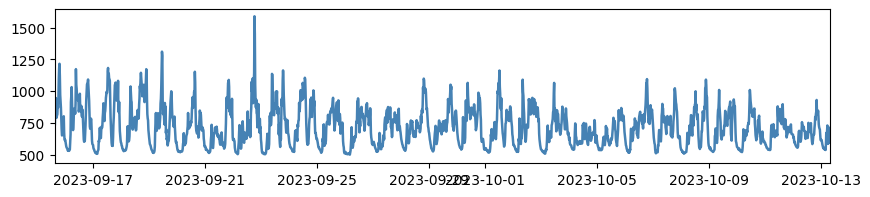

In [ ]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.plot(dates, co2_values, color='steelblue', linewidth=1.8, label='atmos')


ax.set_xlim(dates[12000], dates[-1])

#ax.set_ylim([450,800])
plt.show()


## Check for Outliers and Missing Values

Now split off last 5 years data off into a test data set and train (fit) on remaining data

In [ ]:

# ── 2. Train/test split — hold out last 5 years (60 months) ───────────────────

train_vals = co2_values[0:1000] #co2_values[:-holdout]
test_vals  = co2_values[1001:1160] # co2_values[-holdout:]
train_dates = dates[0:1000]#dates[:-holdout]
test_dates  = dates[1001:1160]#dates[-holdout:]

print(f"Training:  {train_dates[0].strftime('%b %Y')} → {train_dates[-1].strftime('%b %Y')} ({len(train_vals)} months)")
print(f"Test:      {test_dates[0].strftime('%b %Y')} → {test_dates[-1].strftime('%b %Y')} ({len(test_vals)} months)")


Training:  Oct 2022 → Nov 2022 (1000 months)
Test:      Nov 2022 → Nov 2022 (159 months)


## Smoothing `train_vals` with a running average

half period  2


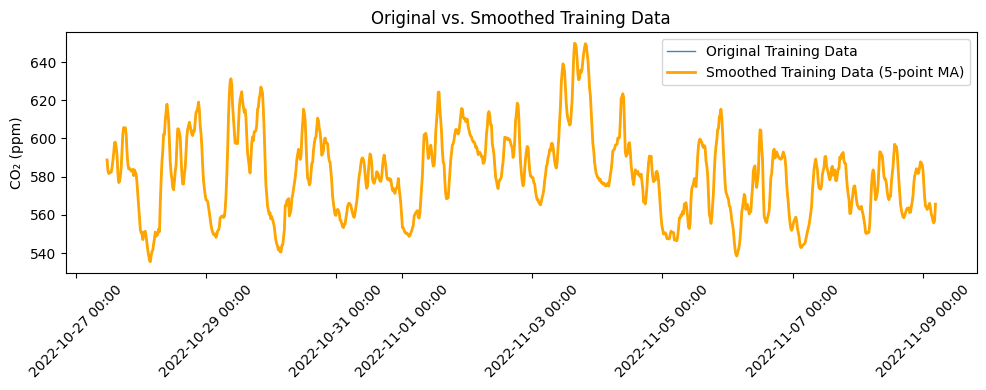

In [ ]:
# Apply a running average of 5 values to train_vals
train_vals = moving_average(train_vals, 5)

# Plot original and smoothed train_vals
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_dates, train_vals, color='steelblue', linewidth=1, label='Original Training Data')
ax.plot(train_dates, smoothed_train_vals, color='orange', linewidth=2, label='Smoothed Training Data (5-point MA)')
ax.set_title('Original vs. Smoothed Training Data')
ax.set_ylabel('CO₂ (ppm)')
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


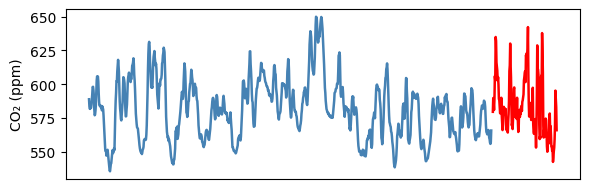

In [ ]:
# ── 3. Plot raw data ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 2))
ax.plot(train_dates, train_vals, color='steelblue', linewidth=1.8, label='atmos')
ax.plot(test_dates,  test_vals,  color='red',     linewidth=1.8, label='Held-out test data')
#ax.set_title('Mauna Loa CO₂ Concentration (ppm)')
ax.set_ylabel('CO₂ (ppm)')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
#ax.legend()
plt.tight_layout()
#plt.savefig('keeling2.png')
plt.show()

(integer) number of data points in 1 period of periodic variation  79
first calc running average over 1 period
half period  39
1000


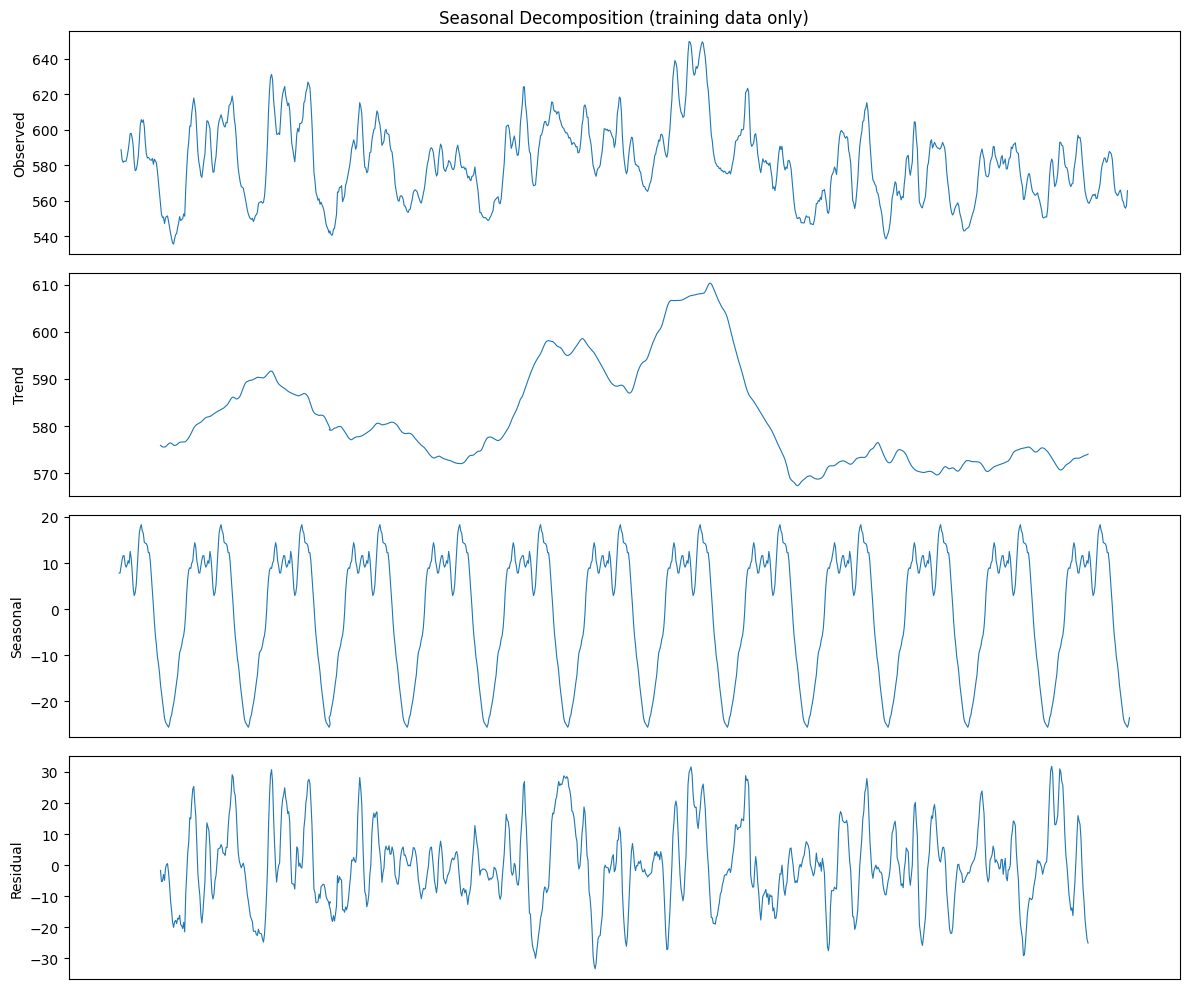

In [ ]:

# ── 4. Manual seasonal decomposition (on training data only) ──────────────────
period = 79
print('(integer) number of data points in 1 period of periodic variation ',period)

def moving_average(x, w):
    out = np.full_like(x, np.nan, dtype=float)
    # // does floor division, ie divide then round down (not to nearest) to integer
    half = w // 2
    print('half period ',half)
    for i in range(half, len(x) - half):
        out[i] = x[i - half : i + half + 1].mean()
    return out
print('first calc running average over 1 period')
trend     = moving_average(train_vals, period)
detrended = train_vals - trend
seasonal  = np.zeros(len(train_vals))
print(len(train_vals))
# now loop over the period, ie over 12 months
for m in range(period):
    # this should array of indices of all data points in month m
    idx   = np.arange(m, len(train_vals), period)
    valid = idx[~np.isnan(detrended[idx])]
    # this computes the mean of the detrended data for month m
    seasonal[idx] = np.nanmean(detrended[valid])
# so residual CO2 value for data point i - trend value
# - mean value of detrended data for that month
residual = train_vals - trend - seasonal

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for ax, data, title in zip(
    axes,
    [train_vals, trend, seasonal, residual],
    ['Observed', 'Trend', 'Seasonal', 'Residual']
):
    ax.plot(train_dates, data, linewidth=0.8)
    ax.set_ylabel(title)
    ax.xaxis.set_major_locator(mdates.YearLocator(10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].set_title('Seasonal Decomposition (training data only)')
#axes[0].set_xlim(train_dates[0], train_dates[24])
plt.tight_layout()
plt.show()

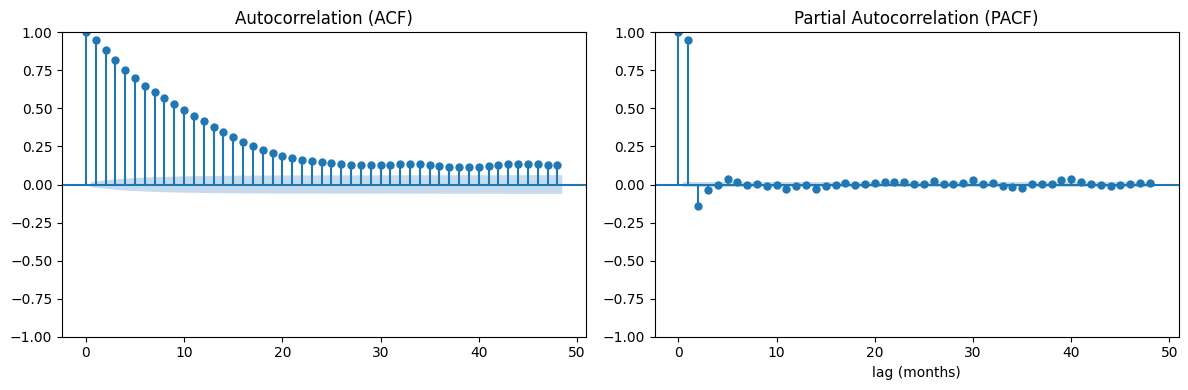

In [ ]:
# ── 4. ACF / PACF ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(co2_values,  lags=48, ax=axes[0], title='Autocorrelation (ACF)')
plot_pacf(co2_values, lags=48, ax=axes[1], title='Partial Autocorrelation (PACF)')
plt.xlabel('lag (months)')
plt.tight_layout()
plt.show()

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 1000
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 79)   Log Likelihood               -2229.538
Date:                            Mon, 11 May 2026   AIC                           4469.076
Time:                                    16:13:00   BIC                           4492.737
Sample:                                         0   HQIC                          4478.145
                                           - 1000                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6117      0.036     16.806      0.000       0.540       0.683
ma.L1          0.0878      0.049   

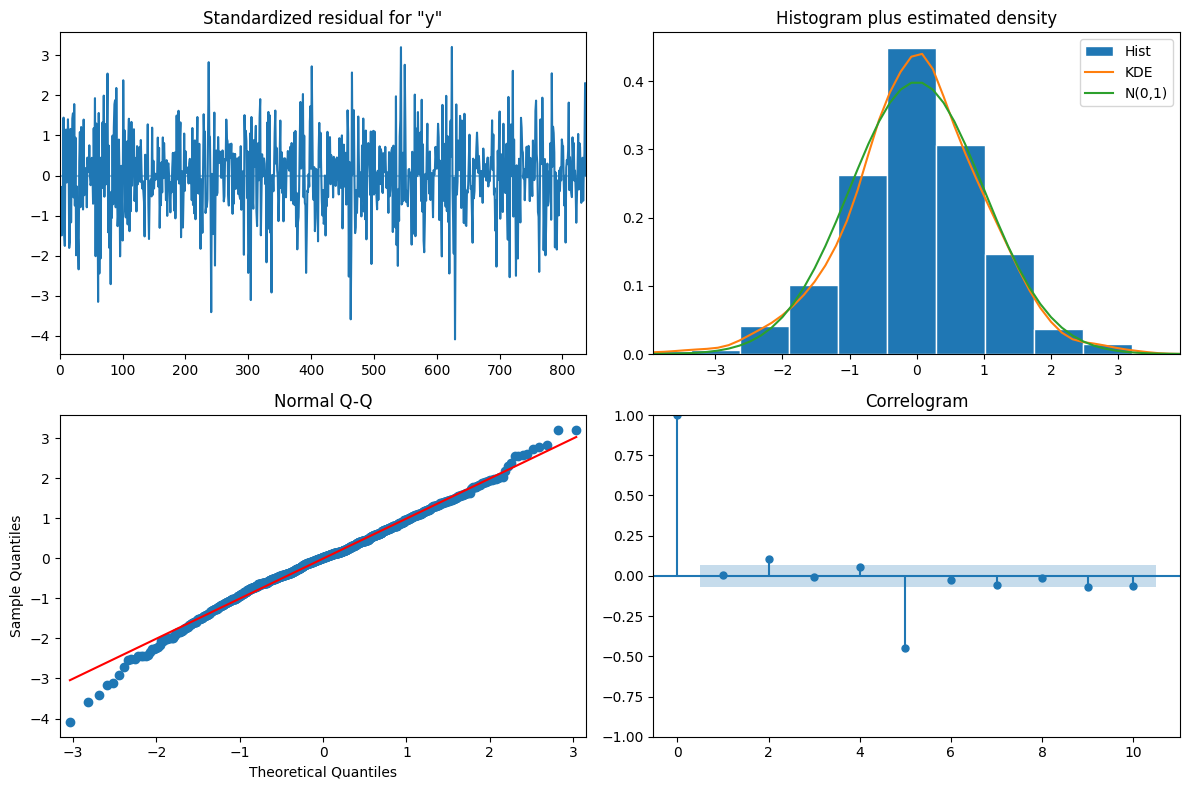

In [ ]:
# ── 6. Fit SARIMA on training data only ───────────────────────────────────────
model = SARIMAX(
    train_vals,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, period),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)
print(results.summary())

# ── 7. Diagnostics ────────────────────────────────────────────────────────────
results.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [ ]:


# ── 8. Forecast over the held-out period and compare ─────────────────────────
holdout=159
print('holdout',holdout)
pred      = results.get_forecast(steps=holdout)
pred_mean = pred.predicted_mean
pred_ci   = pred.conf_int(alpha=0.05)
print(pred_mean)

# Compute error metrics
mae  = np.mean(np.abs(pred_mean - test_vals))
rmse = np.sqrt(np.mean((pred_mean - test_vals) ** 2))
print(f"\nForecast accuracy over held-out 5 years:")
print(f"  MAE:  {mae:.3f} ppm")
print(f"  RMSE: {rmse:.3f} ppm")



holdout 159
[581.19960393 584.17976825 586.10812474 587.58439292 589.4904807
 591.34337791 592.87850472 595.72913051 598.10907198 599.20260043
 600.0400016  601.38319733 601.96915254 603.56327386 605.83345554
 609.80103041 612.26027957 613.74920731 613.70436133 613.54899075
 614.62265061 615.30808146 618.09645255 619.98228706 619.14564208
 616.51973829 615.76621963 614.13019408 613.7361022  615.02031278
 616.20258882 616.86788145 616.77462927 615.24714735 614.61792348
 615.16459198 616.3301418  616.16811145 616.90498868 616.17291046
 613.98764592 610.71598558 609.10855467 609.18139499 610.58379195
 613.41484044 616.67360634 620.41344678 622.25839474 623.35606036
 622.95891462 623.0729481  621.24609428 620.81896267 620.30807319
 619.45255561 618.20291594 618.36507062 616.75004186 613.80132969
 611.0742051  607.98493996 604.46687608 601.36146046 599.23995024
 597.01073483 595.47607747 593.68749466 591.44710278 589.87382475
 587.95926256 585.78606948 584.11221    583.06320342 582.6854345


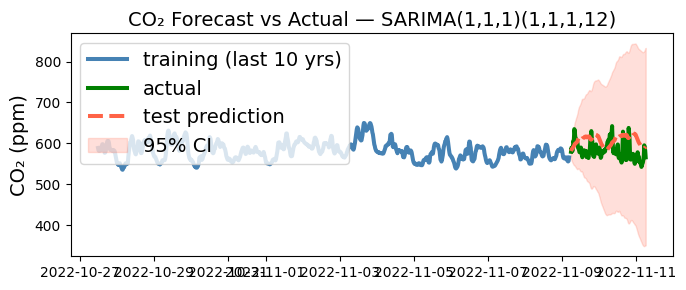


Forecast vs Actual:
        Date    Actual    Forecast     Error    Lower 95    Upper 95
------------------------------------------------------------------
    Nov 2022    579.46      581.20     +1.74      562.35      600.05
    Nov 2022    580.82      587.58     +6.77      553.43      621.74
    Nov 2022    602.88      592.88    -10.00      546.87      638.89
    Nov 2022    615.98      599.20    -16.77      543.52      654.89
    Nov 2022    602.49      601.97     -0.52      538.00      665.94
    Nov 2022    589.02      609.80    +20.78      538.49      681.11
    Nov 2022    578.36      613.70    +35.35      535.73      691.67
    Nov 2022    589.86      615.31    +25.45      531.21      699.41
    Nov 2022    565.93      619.15    +53.21      529.33      708.96
    Nov 2022    583.15      614.13    +30.98      518.94      709.32
    Nov 2022    582.00      616.20    +34.21      515.93      716.48
    Nov 2022    566.26      615.25    +48.99      510.14      720.35
    Nov 2022   

In [ ]:

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(train_dates[:], train_vals[:],
        color='steelblue', linewidth=2.9, label='training (last 10 yrs)')
ax.plot(test_dates, test_vals,
        color='green', linewidth=2.9, label='actual')
ax.plot(test_dates, pred_mean,
        color='tomato', linewidth=2.9, linestyle='--', label='test prediction')
ax.fill_between(test_dates, pred_ci[:, 0], pred_ci[:, 1],
                color='tomato', alpha=0.2, label='95% CI')
#ax.axvline(test_dates[0], color='gray', linestyle=':', linewidth=2.2)#, label='Train/test division')

#ax.plot(dates_2027, pred_2027,
#        color='magenta', linewidth=2.9, linestyle='dotted', label='future')

ax.set_title('CO₂ Forecast vs Actual — SARIMA(1,1,1)(1,1,1,12)',fontsize=14)
ax.set_ylabel('CO₂ (ppm)',fontsize=14)
#ax.xaxis.set_major_locator(mdates.YearLocator(2))
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=14)
plt.tight_layout()
##plt.savefig('Keeling.png',dpi=300)
plt.show()

# ── 9. Forecast table ─────────────────────────────────────────────────────────
print("\nForecast vs Actual:")
print(f"{'Date':>12}  {'Actual':>8}  {'Forecast':>10}  {'Error':>8}  {'Lower 95':>10}  {'Upper 95':>10}")
print("-" * 66)
for i in range(0,60,3):
    error = pred_mean[i] - test_vals[i]
    print(f"{test_dates[i].strftime('%b %Y'):>12}  "
          f"{test_vals[i]:>8.2f}  {pred_mean[i]:>10.2f}  "
          f"{error:>+8.2f}  {pred_ci[i,0]:>10.2f}  {pred_ci[i,1]:>10.2f}")